In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)


## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知

$$
a = [2,-1,3]^\top,\quad b = [1,4,-2]^\top,
$$

$$
A = \begin{bmatrix}
1 & 0 & 2 \\
-1 & 3 & 1
\end{bmatrix},\quad
B = \begin{bmatrix}
2 & 1 \\
0 & -1 \\
3 & 2
\end{bmatrix}.
$$

1. 向量点积：

$$
a \cdot b = 2\times 1 + (-1)\times 4 + 3\times (-2) = 2 - 4 - 6 = -8.
$$

2. 矩阵乘法 $A\times B$：

由于 $A$ 的形状为 $2\times 3$，$B$ 的形状为 $3\times 2$，因此乘积存在，结果矩阵的形状为 $2\times 2$。

$$
AB =
\begin{bmatrix}
1 & 0 & 2 \\
-1 & 3 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 1 \\
0 & -1 \\
3 & 2
\end{bmatrix}
=
\begin{bmatrix}
8 & 5 \\
1 & -2
\end{bmatrix}.
$$

3. 向量 $a$ 的 Frobenius 范数：

向量的 Frobenius 范数与 2 范数相同，因此

$$
\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{14}.
$$


### 2.2 编程题

按要求创建随机矩阵、全 1 矩阵，并完成矩阵乘法与范数计算。


In [2]:
rng = np.random.default_rng(42)

X = rng.standard_normal((3, 4))
Y = np.ones((4, 2))
Z = X @ Y

print("X =")
print(X)
print("\nY =")
print(Y)
print("\nZ = X @ Y =")
print(Z)
print("\nZ 的第一行第二列元素 Z[0, 1] =", Z[0, 1])
print("Z 的第 2 行所有元素 =", Z[1, :])
print("Z 的 Frobenius 范数 =", np.linalg.norm(Z, ord='fro'))


X =
[[ 0.3047 -1.04    0.7505  0.9406]
 [-1.951  -1.3022  0.1278 -0.3162]
 [-0.0168 -0.853   0.8794  0.7778]]

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y =
[[ 0.9557  0.9557]
 [-3.4416 -3.4416]
 [ 0.7873  0.7873]]

Z 的第一行第二列元素 Z[0, 1] = 0.955748885711607
Z 的第 2 行所有元素 = [-3.4416 -3.4416]
Z 的 Frobenius 范数 = 5.172638511887385


## 3 概率与统计

### 3.1 理论计算题

设

- 患病事件为 $D$，则 $P(D)=0.001$；
- 检测阳性事件为 $+$；
- 灵敏度 $P(+|D)=0.99$；
- 假阳性率 $P(+|\bar D)=0.02$。

根据贝叶斯公式，

$$
P(D|+) = \frac{P(+|D)P(D)}{P(+)}.
$$

其中

$$
P(+) = P(+|D)P(D) + P(+|\bar D)P(\bar D)
= 0.99\times 0.001 + 0.02\times 0.999
= 0.02097.
$$

因而

$$
P(D|+) = \frac{0.99\times 0.001}{0.02097}
\approx 0.0472.
$$

所以，一个人检测结果为阳性时，他真正患病的概率约为 **4.72%**。


### 3.2 编程题

用 Python 模拟中心极限定理，并将样本均值的经验分布与理论正态分布进行比较。


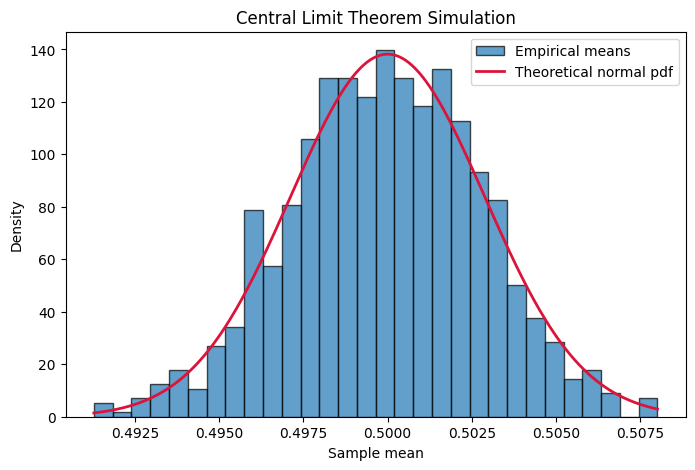

1000 个样本均值的经验均值 = 0.4999200250183204
1000 个样本均值的经验方差 = 7.980910870161384e-06
理论方差 = 8.333333333333334e-06


In [3]:
rng = np.random.default_rng(42)
n = 10000
m = 1000

samples = rng.uniform(0.0, 1.0, size=(m, n))
means = samples.mean(axis=1)

theoretical_mean = 0.5
theoretical_var = 1 / (12 * n)
theoretical_std = np.sqrt(theoretical_var)
empirical_var = means.var(ddof=1)

x = np.linspace(means.min(), means.max(), 400)
normal_pdf = (
    1 / (np.sqrt(2 * np.pi) * theoretical_std)
    * np.exp(-((x - theoretical_mean) ** 2) / (2 * theoretical_std**2))
)

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, edgecolor="black", label="Empirical means")
plt.plot(x, normal_pdf, color="crimson", linewidth=2, label="Theoretical normal pdf")
plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.title("Central Limit Theorem Simulation")
plt.legend()
plt.show()

print("1000 个样本均值的经验均值 =", means.mean())
print("1000 个样本均值的经验方差 =", empirical_var)
print("理论方差 =", theoretical_var)


## 4 导数、反向传播和复杂度

### 4.1 理论计算题

已知

$$
z = (w_1x_1 + w_2x_2 - y)^2,
$$

其中 $x_1=2, x_2=1, y=3$ 为常数，$w_1,w_2$ 为变量。

令

$$
u = w_1x_1 + w_2x_2 - y,
$$

则 $z=u^2$。由链式法则可得

$$
\frac{\partial z}{\partial w_1}
= 2u\frac{\partial u}{\partial w_1}
= 2(w_1x_1 + w_2x_2 - y)x_1,
$$

$$
\frac{\partial z}{\partial w_2}
= 2u\frac{\partial u}{\partial w_2}
= 2(w_1x_1 + w_2x_2 - y)x_2.
$$

当 $w_1=0.5, w_2=1$ 时，

$$
w_1x_1 + w_2x_2 - y = 0.5\times 2 + 1\times 1 - 3 = -1.
$$

因此

$$
\frac{\partial z}{\partial w_1} = 2\times (-1)\times 2 = -4,
$$

$$
\frac{\partial z}{\partial w_2} = 2\times (-1)\times 1 = -2.
$$


### 4.2 编程题

手动实现一个简单计算图的前向传播和反向传播，并与自动微分结果进行核对。


In [4]:
import autograd.numpy as anp
from autograd import grad

x = 2.0
w1 = 1.5
w2 = 0.5

# 前向传播
a = x * w1
b = a + w2
L = b**2

# 手动反向传播
dL_db = 2 * b
dL_dw2_manual = dL_db * 1
dL_da = dL_db * 1
dL_dw1_manual = dL_da * x

print("前向传播结果：")
print("a =", a)
print("b =", b)
print("L =", L)

print("\n手动反向传播梯度：")
print("dL/dw1 =", dL_dw1_manual)
print("dL/dw2 =", dL_dw2_manual)

def loss_fn(params):
    w1_, w2_ = params
    a_ = x * w1_
    b_ = a_ + w2_
    return b_**2

grad_auto = grad(loss_fn)(anp.array([w1, w2]))

print("\n自动微分梯度：")
print("dL/dw1 =", grad_auto[0])
print("dL/dw2 =", grad_auto[1])
print("\n手动结果与自动微分是否一致：", np.allclose([dL_dw1_manual, dL_dw2_manual], grad_auto))


前向传播结果：
a = 3.0
b = 3.5
L = 12.25

手动反向传播梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

自动微分梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

手动结果与自动微分是否一致： True


## 5 线性方法、基础优化和 softmax 回归

### 5.1 理论计算题

设线性回归模型为

$$
\hat y_i = wx_i + b,
$$

均方误差损失为

$$
L = \frac{1}{n}\sum_{i=1}^{n}(y_i - (wx_i+b))^2.
$$

对 $w$ 求偏导：

$$
\frac{\partial L}{\partial w}
= \frac{1}{n}\sum_{i=1}^{n} 2(y_i-(wx_i+b))\cdot(-x_i)
= -\frac{2}{n}\sum_{i=1}^{n}(y_i-(wx_i+b))x_i.
$$

等价地，也可以写成

$$
\frac{\partial L}{\partial w}
= \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i.
$$

对 $b$ 求偏导：

$$
\frac{\partial L}{\partial b}
= \frac{1}{n}\sum_{i=1}^{n} 2(y_i-(wx_i+b))\cdot(-1)
= -\frac{2}{n}\sum_{i=1}^{n}(y_i-(wx_i+b)).
$$

等价地，

$$
\frac{\partial L}{\partial b}
= \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i).
$$


### 5.2 编程题

从零实现 softmax 回归，并在 `load_digits()` 数据集上完成多分类训练与测试。


Epoch 10: loss=0.4376, train_acc=0.1030
Epoch 20: loss=0.2920, train_acc=0.1058
Epoch 30: loss=0.2345, train_acc=0.1030
Epoch 40: loss=0.2021, train_acc=0.1023
Epoch 50: loss=0.1806, train_acc=0.1058


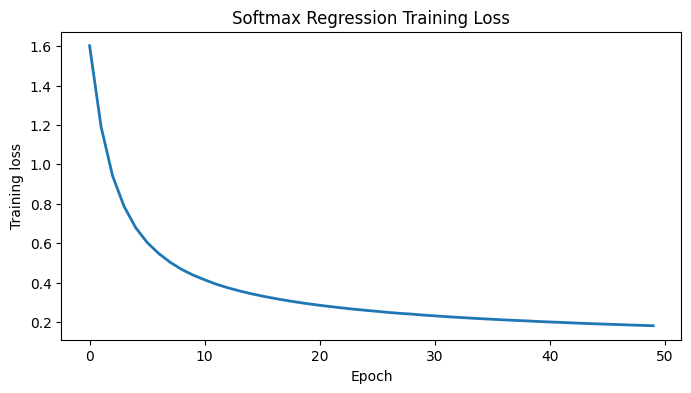

测试集准确率 = 0.9527777777777777


In [5]:
rng = np.random.default_rng(42)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target
num_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train_onehot = np.eye(num_classes)[y_train]
y_test_onehot = np.eye(num_classes)[y_test]

W = rng.normal(0.0, 0.01, size=(X_train.shape[1], num_classes))
b = np.zeros(num_classes)

batch_size = 32
lr = 0.1
epochs = 50

def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

def cross_entropy(y_true, probs):
    return -np.mean(np.sum(y_true * np.log(probs + 1e-12), axis=1))

num_train = X_train.shape[0]
indices = np.arange(num_train)
loss_history = []

for epoch in range(epochs):
    rng.shuffle(indices)
    X_train = X_train[indices]
    y_train_onehot = y_train_onehot[indices]

    for start in range(0, num_train, batch_size):
        end = start + batch_size
        xb = X_train[start:end]
        yb = y_train_onehot[start:end]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T @ grad_logits
        grad_b = grad_logits.sum(axis=0)

        W -= lr * grad_W
        b -= lr * grad_b

    train_probs = softmax(X_train @ W + b)
    train_loss = cross_entropy(y_train_onehot, train_probs)
    loss_history.append(train_loss)

    if (epoch + 1) % 10 == 0:
        train_pred = train_probs.argmax(axis=1)
        train_acc = (train_pred == y_train).mean()
        print(f"Epoch {epoch + 1:02d}: loss={train_loss:.4f}, train_acc={train_acc:.4f}")

test_probs = softmax(X_test @ W + b)
test_pred = test_probs.argmax(axis=1)
test_acc = (test_pred == y_test).mean()

plt.figure(figsize=(8, 4))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Softmax Regression Training Loss")
plt.show()

print("测试集准确率 =", test_acc)


## 6 最大似然估计和逻辑回归

### 6.1 理论计算题

设样本 $x_1,x_2,\dots,x_n$ 独立同分布于正态分布 $N(\mu,\sigma^2)$。

1. 似然函数

单个样本的概率密度为

$$
f(x_i|\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right).
$$

因此总体似然函数为

$$
L(\mu,\sigma^2)
= \prod_{i=1}^{n} f(x_i|\mu,\sigma^2)
= (2\pi\sigma^2)^{-n/2}
\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2\right).
$$

取对数似然：

$$
\ell(\mu,\sigma^2)
= -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2)
- \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2.
$$

2. 证明 $\mu$ 的最大似然估计

对 $\mu$ 求导：

$$
\frac{\partial \ell}{\partial \mu}
= -\frac{1}{2\sigma^2}\cdot 2\sum_{i=1}^{n}(x_i-\mu)(-1)
= \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu).
$$

令其为 0：

$$
\sum_{i=1}^{n}(x_i-\mu)=0
\Rightarrow
n\mu = \sum_{i=1}^{n}x_i
\Rightarrow
\hat\mu = \frac{1}{n}\sum_{i=1}^{n}x_i.
$$

3. 证明 $\sigma^2$ 的最大似然估计

对 $\sigma^2$ 求导：

$$
\frac{\partial \ell}{\partial \sigma^2}
= -\frac{n}{2\sigma^2}
+ \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2.
$$

令其为 0，可得

$$
-\frac{n}{2\sigma^2}
+ \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2 = 0.
$$

两边同时乘以 $2(\sigma^2)^2$：

$$
-n\sigma^2 + \sum_{i=1}^{n}(x_i-\mu)^2 = 0
\Rightarrow
\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2.
$$

将 $\mu$ 替换为其极大似然估计 $\hat\mu$，得到

$$
\hat\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2.
$$


### 6.2 编程题

从零实现一个二分类逻辑回归模型，训练后绘制决策边界，并在新生成测试集上评估准确率。


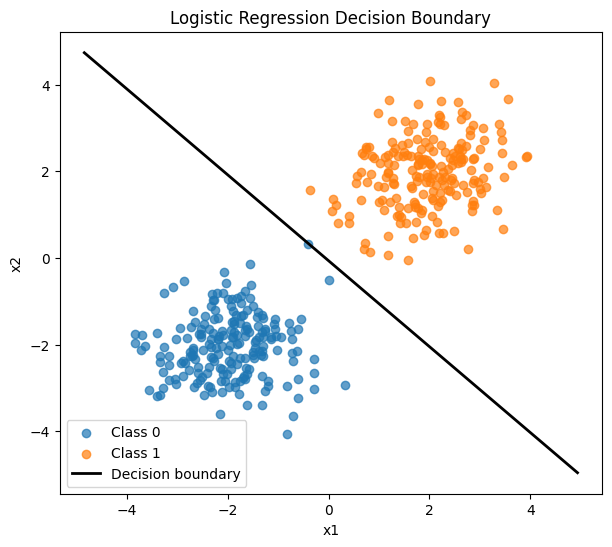

学习到的参数 w = [1.9338 1.9532]
学习到的参数 b = 0.1287122018361984
测试集准确率 = 1.0


In [6]:
rng = np.random.default_rng(42)

# 生成两类线性可分数据
class0 = rng.normal(loc=[-2, -2], scale=0.8, size=(200, 2))
class1 = rng.normal(loc=[2, 2], scale=0.8, size=(200, 2))
X_train = np.vstack([class0, class1])
y_train = np.concatenate([np.zeros(200), np.ones(200)])

perm = rng.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

w = np.zeros(X_train.shape[1])
b = 0.0
lr = 0.1
num_iters = 1000
loss_history = []

for _ in range(num_iters):
    logits = X_train @ w + b
    probs = sigmoid(logits)
    loss = binary_cross_entropy(y_train, probs)
    loss_history.append(loss)

    error = probs - y_train
    grad_w = X_train.T @ error / len(X_train)
    grad_b = error.mean()

    w -= lr * grad_w
    b -= lr * grad_b

# 新生成测试集（100 个样本）
class0_test = rng.normal(loc=[-2, -2], scale=0.8, size=(50, 2))
class1_test = rng.normal(loc=[2, 2], scale=0.8, size=(50, 2))
X_test = np.vstack([class0_test, class1_test])
y_test = np.concatenate([np.zeros(50), np.ones(50)])

test_probs = sigmoid(X_test @ w + b)
test_pred = (test_probs >= 0.5).astype(int)
test_acc = (test_pred == y_test).mean()

plt.figure(figsize=(7, 6))
plt.scatter(class0[:, 0], class0[:, 1], label="Class 0", alpha=0.7)
plt.scatter(class1[:, 0], class1[:, 1], label="Class 1", alpha=0.7)

x_vals = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 200)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, color="black", linewidth=2, label="Decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

print("学习到的参数 w =", w)
print("学习到的参数 b =", b)
print("测试集准确率 =", test_acc)
